In [1]:
import pandas as pd


In [2]:
def sanity_checker(robustipy_class: str) -> pd.DataFrame:
    """
    Perform sanity checks on the results CSV corresponding to a robustipy class.
    
    This function reads a CSV file with the pattern:
        ../time_profiler_{robustipy_class}_results.csv
    and verifies:
      - Total row count.
      - Counts of unique controls, runs, draws, and folds.
      - Expected counts for rows where Folds==10 and Draws==10000.
      - The number of duplicate rows based on specific columns.
    
    Parameters
    ----------
    robustipy_class : str
        An identifier to construct the CSV filename.
    
    Returns
    -------
    pd.DataFrame
        The DataFrame loaded from the CSV file.
    """
    # Construct file path and load data
    file_path = f'../data/time_profiler/time_profiler_{robustipy_class}_results.csv'
    df = pd.read_csv(file_path)
    
    # Expected constants
    n_uniq_controls = 5
    n_draw_points = 25
    n_folds = 6
    n_runs = 10

    # Calculate expected counts
    expected_folds_count = n_uniq_controls * n_draw_points * n_runs
    expected_draws_count = n_uniq_controls * n_folds * n_runs
    expected_total = n_uniq_controls * n_runs * (n_draw_points + (n_folds - 1))
    
    # Define subset of columns for duplicate detection
    unique_columns = [
        'Control_Set_Index', 'Control_Set_Length', 
        'Draws', 'Run_Number', 'Folds'
    ]
    duplicate_count = len(df) - len(df.drop_duplicates(subset=unique_columns))
    
    # Compute unique counts
    control_count = len(df['Control_Set_Length'].unique())
    run_count = len(df['Run_Number'].unique())
    draw_count = len(df['Draws'].unique())
    fold_count = len(df['Folds'].unique())
    
    # Compute conditional counts
    folds_10_count = len(df[df['Folds'] == 10])
    draws_10000_count = len(df[df['Draws'] == 10000])
    
    # Print summary statistics
    print(f'Total number of rows: {len(df)}')
    print(f'Total number of rows expected: ', expected_total)
    print(f'Unique controls (expected {n_uniq_controls}): {control_count}')
    print(f'Unique runs (expected {n_runs}): {run_count}')
    print(f'Unique draws (expected {n_draw_points}): {draw_count}')
    print(f'Unique folds (expected {n_folds}): {fold_count}')
    print(
        f'For Folds==10, expected count: {expected_folds_count}, found: '
        f'{folds_10_count}'
    )
    print(
        f'For Draws==10000, expected count: {expected_draws_count}, found: '
        f'{draws_10000_count}'
    )
    print(f'Number of duplicate rows (expected 0): {duplicate_count}')
    
    return df

In [3]:
ols = sanity_checker('OLS')

Total number of rows: 1500
Total number of rows expected:  1500
Unique controls (expected 5): 5
Unique runs (expected 10): 10
Unique draws (expected 25): 25
Unique folds (expected 6): 6
For Folds==10, expected count: 1250, found: 1250
For Draws==10000, expected count: 300, found: 300
Number of duplicate rows (expected 0): 0


In [4]:
lr = sanity_checker('LR')

Total number of rows: 1500
Total number of rows expected:  1500
Unique controls (expected 5): 5
Unique runs (expected 10): 10
Unique draws (expected 25): 25
Unique folds (expected 6): 6
For Folds==10, expected count: 1250, found: 1250
For Draws==10000, expected count: 300, found: 300
Number of duplicate rows (expected 0): 0


In [5]:
temp = ols[(ols['Control_Set_Length'] == 6) & (ols['Draws'] == 10000)]
grouped = temp.groupby('Folds')['Time_Taken_s']
folds = grouped.mean().index  # assume sorted
median = grouped.median()
min_vals = grouped.min()
max_vals = grouped.max()
print(temp)
print(folds)
print(median)
print(max_vals)

      Control_Set_Index  Control_Set_Length  Draws  Run_Number  Folds  \
924                   3                   6  10000           1     10   
925                   3                   6  10000           1      2   
926                   3                   6  10000           1      5   
927                   3                   6  10000           1     15   
928                   3                   6  10000           1     20   
929                   3                   6  10000           1     25   
954                   3                   6  10000           2     10   
955                   3                   6  10000           2      2   
956                   3                   6  10000           2      5   
957                   3                   6  10000           2     15   
958                   3                   6  10000           2     20   
959                   3                   6  10000           2     25   
984                   3                   6  10000 

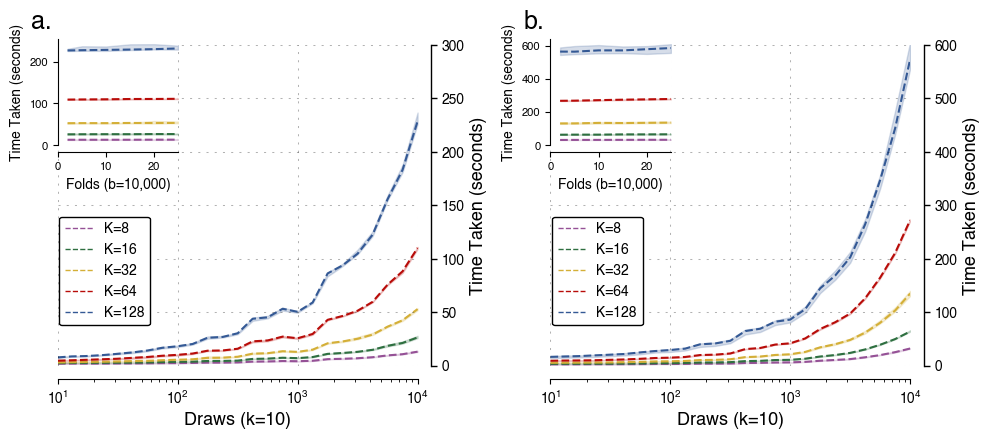

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from robustipy.utils import get_colormap_colors
colors = get_colormap_colors(5)
colors.reverse()
# Global font
plt.rcParams['font.family'] = 'Helvetica'

# Color palette
#colors = ["#d53e4f", "#fc8d59", "#fee08b", "#99d594", "#3288bd"]

# Prepare figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

# Configure grid, spines, and tick settings for both axes
for ax in [ax1, ax2]:
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.tick_params(axis='y', which='both', left=False, right=True,
                   direction='out', length=4, width=1)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(True)
    ax.spines['right'].set_linewidth(1)
    ax.spines['right'].set_position(('outward', 0))
    ax.set_axisbelow(False)  # ticks above grid
    ax.grid(True, axis='both', linestyle=(0, (2, 6)),
            linewidth=0.74, alpha=0.3, color='k', zorder=3)
    sns.despine(ax=ax, left=True, top=True, right=False, bottom=False)

# --- Main plot for OLS (ax1) ---
for i, csl in enumerate([3, 4, 5, 6, 7]):
    df = ols[(ols['Folds'] == 10) & (ols['Control_Set_Length'] == csl)]
    grouped = df.groupby('Draws')['Time_Taken_s']
    draws = grouped.mean().index
    median = grouped.median()
    min_vals = grouped.min()
    max_vals = grouped.max()
    ax1.plot(draws, median, linestyle='--', label=f'CSL={csl}', color=colors[i], zorder=2)
    ax1.fill_between(draws, min_vals, max_vals, alpha=0.2, color=colors[i], zorder=2)
ax1.set_xscale('log')
ax1.set_xlabel('Draws (k=10)', fontsize=13)
ax1.set_ylabel('Time Taken (seconds)', fontsize=13)

# --- Main plot for LR (ax2) ---
for i, csl in enumerate([3, 4, 5, 6, 7]):
    df = lr[(lr['Folds'] == 10) & (lr['Control_Set_Length'] == csl)]
    grouped = df.groupby('Draws')['Time_Taken_s']
    draws = grouped.mean().index
    median = grouped.median()
    min_vals = grouped.min()
    max_vals = grouped.max()
    ax2.plot(draws, median, linestyle='--', label=f'CSL={csl}', color=colors[i], zorder=2)
    ax2.fill_between(draws, min_vals, max_vals, alpha=0.2, color=colors[i], zorder=2)
ax2.set_xscale('log')
ax2.set_xlabel('Draws (k=10)', fontsize=13)
ax2.set_ylabel('Time Taken (seconds)', fontsize=13)

# --- Inset creation function (with annotations written out manually) ---
def add_combined_inset(ax, df_source):
    inset_ax = ax.inset_axes([0.00, 0.6875, 0.335, 0.33])  # [x0, y0, width, height]
    all_y_vals = []
    
    # Plot each CSL’s line using a loop (acceptable for plotting)
    for i, csl in enumerate([3, 4, 5, 6, 7]):
        df = df_source[(df_source['Control_Set_Length'] == csl) & (df_source['Draws'] == 10000)]
        grouped = df.groupby('Folds')['Time_Taken_s']
        folds = grouped.mean().index  # assume sorted
        median = grouped.median()
        min_vals = grouped.min()
        max_vals = grouped.max()
        inset_ax.plot(folds, median, linestyle='--', marker=None, color=colors[i],
                      label=f'CSL={csl}', zorder=2)
        inset_ax.fill_between(folds, min_vals, max_vals, alpha=0.2, color=colors[i])
        all_y_vals.extend(min_vals.tolist())
        all_y_vals.extend(max_vals.tolist())
    
    # Set shared y–limits with a small padding.
#    ymin, ymax = min(all_y_vals), max(all_y_vals)
#    ypad = (ymax - ymin) * 0.05 if ymax > ymin else 1
    inset_ax.set_ylim(0, inset_ax.get_ylim()[1])
    
    inset_ax.set_xlim(0, 25)
    inset_ax.set_xlabel("Folds (b=10,000)", fontsize=10)
    inset_ax.set_ylabel('Time Taken (seconds)', fontsize=10)
    inset_ax.tick_params(labelsize=8)
    inset_ax.spines['top'].set_visible(False)
    inset_ax.spines['right'].set_visible(False)
    inset_ax.spines['bottom'].set_position(('outward', 5))
    inset_ax.spines['right'].set_position(('outward', 5))
    return inset_ax

# Add combined insets (with annotations) to both axes.
inset_ax_ols = add_combined_inset(ax1, ols)
inset_ax_lr  = add_combined_inset(ax2, lr)

# --- Titles, spine positions, and axis limits for main axes ---
ax1.set_title('a.', loc='left', fontsize=18, y=1.025, x=-0.075)
ax2.set_title('b.', loc='left', fontsize=18, y=1.025, x=-0.075)
ax1.spines['bottom'].set_position(('outward', 10))
ax1.spines['right'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 10))
ax2.spines['right'].set_position(('outward', 10))
ax1.set_ylim(0, 300)
ax2.set_ylim(0, 600)
ax1.set_xlim(10, 10000)
ax2.set_xlim(10, 10000)




legend_elements1 = [Line2D([0], [0], color=colors[0], lw=1, linestyle='--',
                           label=r'K=8', alpha=1),
                    Line2D([0], [0], color=colors[1], lw=1, linestyle='--',
                           label=r'K=16', alpha=1),
                    Line2D([0], [0], color=colors[2], lw=1, linestyle='--',
                           label=r'K=32', alpha=1),
                    Line2D([0], [0], color=colors[3], lw=1, linestyle='--',
                           label=r'K=64', alpha=1),
                    Line2D([0], [0], color=colors[4], lw=1, linestyle='--',
                           label=r'K=128', alpha=1),
 ]

for ax in [ax1, ax2]:
    ax.legend(handles=legend_elements1,
              loc='center left',
              bbox_to_anchor=(-0.015, 0.295),  # adjust y-coordinate as needed
              frameon=True,
              fontsize=10,
              framealpha=1,
              facecolor='w',
              ncols=1,
              edgecolor=(0, 0, 0, 1)
             )



plt.tight_layout()




plt.savefig("../figures/time_profiler/time_profiler.pdf", bbox_inches='tight')
plt.savefig("../figures/time_profiler/time_profiler.png", bbox_inches='tight', dpi=400)
plt.savefig("../figures/time_profiler/time_profiler.svg", bbox_inches='tight')

# How many regressions do we run?

In [ ]:
temp = ols[ols['Run_Number']==1]
temp['2^(Control_Set_Length)'] = 2 ** temp['Control_Set_Length']
total = ((temp['2^(Control_Set_Length)'] * temp['Draws']) +
         (temp['2^(Control_Set_Length)'] * temp['Folds'])).sum()
total*ols['Run_Number'].unique().max()*3

In [ ]:
ols['Run_Number'].unique().max()